In [45]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              mean_absolute_error, r2_score)
import mlflow
import mlflow.pytorch
import warnings
warnings.filterwarnings('ignore')

# Set all random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Random seed: {SEED} (results will be identical every run)")

Using device: cpu
PyTorch version: 2.11.0+cpu
Random seed: 42 (results will be identical every run)


In [46]:
df = pd.read_csv("../data/processed/features.csv")
df = df.sort_values(['Email', 'assignment_order']).reset_index(drop=True)

print(f"Loaded: {df.shape}")
print(f"Students: {df['Email'].nunique()}")
print(f"Assignments per student: {df.groupby('Email').size().unique()}")

students = df['Email'].unique()
np.random.seed(42)
np.random.shuffle(students)
split_idx = int(len(students) * 0.8)
train_students = students[:split_idx]
test_students  = students[split_idx:]

df_train = df[df['Email'].isin(train_students)].copy()
df_test  = df[df['Email'].isin(test_students)].copy()

print(f"\nTrain: {len(train_students)} students, {len(df_train)} rows")
print(f"Test:  {len(test_students)} students, {len(df_test)} rows")

FEATURE_COLS = [
    'grade_pct', 'time_minutes', 'never_started',
    'grade_zscore', 'time_zscore', 'effort_efficiency',
    'class_skip_rate', 'grade_velocity', 'time_velocity',
    'rolling_avg_grade_3', 'cumulative_skips',
    'cumulative_avg_grade', 'difficulty_score'
]

scaler = StandardScaler()
df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])

print("\nFeature scaling applied.")
print(f"Input features: {len(FEATURE_COLS)}")

Loaded: (588, 18)
Students: 42
Assignments per student: [14]

Train: 33 students, 462 rows
Test:  9 students, 126 rows

Feature scaling applied.
Input features: 13


In [47]:
class StudentSequenceDataset(Dataset):
    def __init__(self, dataframe, feature_cols):
        self.sequences = []
        self.grade_targets = []
        self.risk_labels   = []
        self.student_ids   = []

        for student_email, group in dataframe.groupby('Email'):
            group = group.sort_values('assignment_order')
            features      = group[feature_cols].values.astype(np.float32)
            grade_targets = (group['next_grade'].values / 100.0).astype(np.float32)
            risk_label    = float(group['at_risk'].iloc[0])

            self.sequences.append(torch.tensor(features))
            self.grade_targets.append(torch.tensor(grade_targets))
            self.risk_labels.append(torch.tensor(risk_label))
            self.student_ids.append(student_email)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (self.sequences[idx],
                self.grade_targets[idx],
                self.risk_labels[idx])

train_dataset = StudentSequenceDataset(df_train, FEATURE_COLS)
test_dataset  = StudentSequenceDataset(df_test,  FEATURE_COLS)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f"Train dataset: {len(train_dataset)} students")
print(f"Test dataset:  {len(test_dataset)} students")
print(f"\nSample batch shapes:")
for features, grades, risks in train_loader:
    print(f"  Features:      {features.shape}")
    print(f"  Grade targets: {grades.shape}")
    print(f"  Risk labels:   {risks.shape}")
    break

Train dataset: 33 students
Test dataset:  9 students

Sample batch shapes:
  Features:      torch.Size([16, 14, 13])
  Grade targets: torch.Size([16, 14])
  Risk labels:   torch.Size([16])


In [48]:
class AcademicGRU(nn.Module):
    def __init__(self, input_size=13, hidden_size=64,
                 num_layers=2, dropout=0.3):
        super(AcademicGRU, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout   = nn.Dropout(dropout)
        self.attention = nn.Linear(hidden_size, 1)

        self.grade_head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

        self.risk_head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size,
                         self.hidden_size).to(x.device)

        gru_out, hidden = self.gru(x, h0)
        gru_out = self.dropout(gru_out)

        attn_scores  = self.attention(gru_out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context      = (attn_weights * gru_out).sum(dim=1)

        grade_pred = self.grade_head(gru_out).squeeze(-1)
        risk_pred  = self.risk_head(context).squeeze(-1)

        return grade_pred, risk_pred, attn_weights.squeeze(-1)


model = AcademicGRU(
    input_size=13,
    hidden_size=64,
    num_layers=2,
    dropout=0.3
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:")
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"\nModel moved to: {device}")

Model architecture:
AcademicGRU(
  (gru): GRU(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (attention): Linear(in_features=64, out_features=1, bias=True)
  (grade_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
  (risk_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Total trainable parameters: 44,419

Model moved to: cpu


In [49]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=10, factor=0.5
)

criterion_grade = nn.MSELoss()
criterion_risk  = nn.BCELoss()

N_EPOCHS = 150
ALPHA    = 0.5
BETA     = 0.5

print("Training configuration:")
print(f"  Optimizer:    AdamW (lr=0.001, weight_decay=1e-4)")
print(f"  Grade loss:   MSELoss  (weight: {ALPHA})")
print(f"  Risk loss:    BCELoss  (weight: {BETA})")
print(f"  Epochs:       {N_EPOCHS}")
print(f"  Batch size:   16")
print(f"\nCombined loss = {ALPHA} x MSE(grade) + {BETA} x BCE(risk)")

Training configuration:
  Optimizer:    AdamW (lr=0.001, weight_decay=1e-4)
  Grade loss:   MSELoss  (weight: 0.5)
  Risk loss:    BCELoss  (weight: 0.5)
  Epochs:       150
  Batch size:   16

Combined loss = 0.5 x MSE(grade) + 0.5 x BCE(risk)


In [50]:
mlflow.end_run()

train_losses = []
val_losses   = []
best_val_loss = float('inf')
best_model_state = None

mlflow.set_experiment("academic_performance_gru")

with mlflow.start_run(run_name="gru_v1_multitask"):

    mlflow.log_params({
        "model": "GRU_v1",
        "hidden_size": 64,
        "num_layers": 2,
        "dropout": 0.3,
        "epochs": N_EPOCHS,
        "lr": 0.001,
        "alpha_grade": ALPHA,
        "beta_risk": BETA,
    })

    for epoch in range(N_EPOCHS):

        model.train()
        train_loss = 0.0

        for features, grade_targets, risk_labels in train_loader:
            features      = features.to(device)
            grade_targets = grade_targets.to(device)
            risk_labels   = risk_labels.to(device).float()

            optimizer.zero_grad()
            grade_pred, risk_pred, _ = model(features)

            loss_grade = criterion_grade(grade_pred, grade_targets)
            loss_risk  = criterion_risk(risk_pred, risk_labels)
            loss = ALPHA * loss_grade + BETA * loss_risk

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for features, grade_targets, risk_labels in test_loader:
                features      = features.to(device)
                grade_targets = grade_targets.to(device)
                risk_labels   = risk_labels.to(device).float()

                grade_pred, risk_pred, _ = model(features)
                loss_grade = criterion_grade(grade_pred, grade_targets)
                loss_risk  = criterion_risk(risk_pred, risk_labels)
                loss = ALPHA * loss_grade + BETA * loss_risk
                val_loss += loss.item()

        avg_val_loss = val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss    = avg_val_loss
            best_model_state = model.state_dict().copy()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    print(f"\nBest validation loss: {best_val_loss:.4f}")
    mlflow.log_metric("best_val_loss", best_val_loss)

Epoch  10/150 | Train Loss: 0.4386 | Val Loss: 0.3863 | LR: 0.001000
Epoch  20/150 | Train Loss: 0.3036 | Val Loss: 0.2797 | LR: 0.001000
Epoch  30/150 | Train Loss: 0.1690 | Val Loss: 0.1489 | LR: 0.001000
Epoch  40/150 | Train Loss: 0.1157 | Val Loss: 0.1094 | LR: 0.001000
Epoch  50/150 | Train Loss: 0.1012 | Val Loss: 0.0942 | LR: 0.001000
Epoch  60/150 | Train Loss: 0.0478 | Val Loss: 0.1335 | LR: 0.001000
Epoch  70/150 | Train Loss: 0.0488 | Val Loss: 0.1404 | LR: 0.001000
Epoch  80/150 | Train Loss: 0.0583 | Val Loss: 0.1707 | LR: 0.000500
Epoch  90/150 | Train Loss: 0.0537 | Val Loss: 0.1791 | LR: 0.000250
Epoch 100/150 | Train Loss: 0.0720 | Val Loss: 0.2021 | LR: 0.000125
Epoch 110/150 | Train Loss: 0.0456 | Val Loss: 0.1918 | LR: 0.000125
Epoch 120/150 | Train Loss: 0.0526 | Val Loss: 0.2040 | LR: 0.000063
Epoch 130/150 | Train Loss: 0.0628 | Val Loss: 0.2028 | LR: 0.000031
Epoch 140/150 | Train Loss: 0.0510 | Val Loss: 0.2125 | LR: 0.000016
Epoch 150/150 | Train Loss: 0.0448

In [51]:
model.load_state_dict(best_model_state)
model.eval()

all_grade_preds  = []
all_grade_true   = []
all_risk_preds   = []
all_risk_true    = []
all_attn_weights = []

with torch.no_grad():
    for features, grade_targets, risk_labels in test_loader:
        features = features.to(device)

        grade_pred, risk_pred, attn = model(features)

        all_grade_preds.extend((grade_pred.cpu().numpy() * 100).flatten())
        all_grade_true.extend((grade_targets.numpy() * 100).flatten())

        risk_binary = (risk_pred.cpu().numpy() > 0.5).astype(int)
        all_risk_preds.extend(risk_binary)
        all_risk_true.extend(risk_labels.numpy().astype(int))

        all_attn_weights.append(attn.cpu().numpy())

grade_mae = mean_absolute_error(all_grade_true, all_grade_preds)
grade_r2  = r2_score(all_grade_true, all_grade_preds)
risk_acc  = accuracy_score(all_risk_true, all_risk_preds)

print("=" * 55)
print("GRU v1 — Results vs Baselines")
print("=" * 55)
print()
print("CLASSIFICATION (at-risk prediction):")
print(f"  GRU accuracy:          {risk_acc*100:.1f}%")
print(f"  Logistic Regression:   88.3%")
print(f"  Random Forest:         86.5%")
print()
print("REGRESSION (next assignment grade):")
print(f"  GRU MAE:               {grade_mae:.2f} points")
print(f"  GRU R2:                {grade_r2:.3f}")
print(f"  Random Forest MAE:     15.51 points")
print(f"  Random Forest R2:      0.750")
print()
print("Detailed classification breakdown:")
print(classification_report(all_risk_true, all_risk_preds,
                            target_names=['Not At Risk', 'At Risk']))

mlflow.log_metrics({
    "gru_grade_mae": grade_mae,
    "gru_grade_r2":  grade_r2,
    "gru_risk_accuracy": risk_acc
})

GRU v1 — Results vs Baselines

CLASSIFICATION (at-risk prediction):
  GRU accuracy:          88.9%
  Logistic Regression:   88.3%
  Random Forest:         86.5%

REGRESSION (next assignment grade):
  GRU MAE:               22.18 points
  GRU R2:                0.197
  Random Forest MAE:     15.51 points
  Random Forest R2:      0.750

Detailed classification breakdown:
              precision    recall  f1-score   support

 Not At Risk       1.00      0.83      0.91         6
     At Risk       0.75      1.00      0.86         3

    accuracy                           0.89         9
   macro avg       0.88      0.92      0.88         9
weighted avg       0.92      0.89      0.89         9



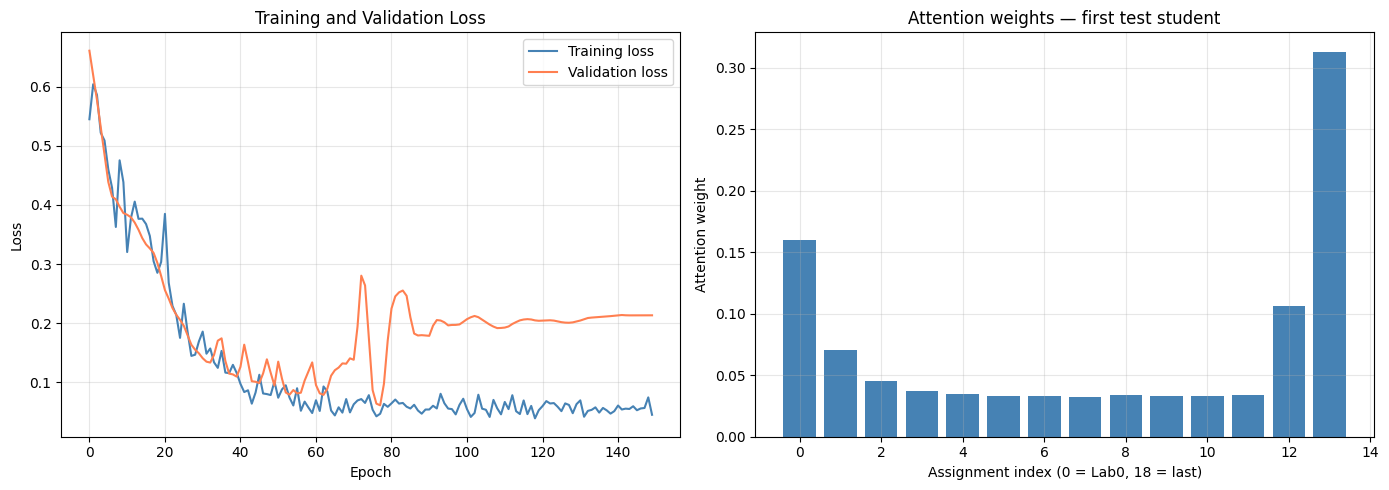

Training curves saved.


In [52]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Training loss', color='steelblue')
ax1.plot(val_losses,   label='Validation loss', color='coral')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

attn_matrix = all_attn_weights[0]
ax2.bar(range(len(attn_matrix[0])), attn_matrix[0], color='steelblue')
ax2.set_title('Attention weights — first test student')
ax2.set_xlabel('Assignment index (0 = Lab0, 18 = last)')
ax2.set_ylabel('Attention weight')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/predictions/gru_training_curves.png", dpi=150)
plt.show()

print("Training curves saved.")

In [53]:
import os

os.makedirs("../outputs/models", exist_ok=True)
torch.save({
    'model_state_dict': best_model_state,
    'model_config': {
        'input_size': 13,
        'hidden_size': 64,
        'num_layers': 2,
        'dropout': 0.3
    },
    'scaler': scaler,
    'feature_cols': FEATURE_COLS,
    'train_students': list(train_students),
    'test_students': list(test_students),
    'metrics': {
        'grade_mae': grade_mae,
        'grade_r2':  grade_r2,
        'risk_accuracy': risk_acc
    }
}, "../outputs/models/gru_v1.pth")

print("Model saved: outputs/models/gru_v1.pth")
print()
print("Phase 4 complete.")
print()
print("Summary of all results so far:")
print(f"  Logistic Regression:  88.3% accuracy")
print(f"  Random Forest clf:    86.5% accuracy")
print(f"  GRU v1:               {risk_acc*100:.1f}% accuracy")
print()
print(f"  RF Regression MAE:    15.51 points")
print(f"  GRU v1 MAE:           {grade_mae:.2f} points")

Model saved: outputs/models/gru_v1.pth

Phase 4 complete.

Summary of all results so far:
  Logistic Regression:  88.3% accuracy
  Random Forest clf:    86.5% accuracy
  GRU v1:               88.9% accuracy

  RF Regression MAE:    15.51 points
  GRU v1 MAE:           22.18 points
